<a href="https://colab.research.google.com/github/Xskyis/Pembelajaran-Mesin-2026/blob/main/TG4_244107020001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1
## KMeans


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Seleksi fitur

In [14]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

Plot data

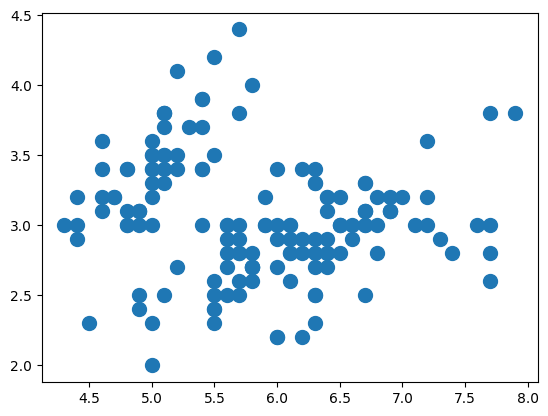

In [15]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [16]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

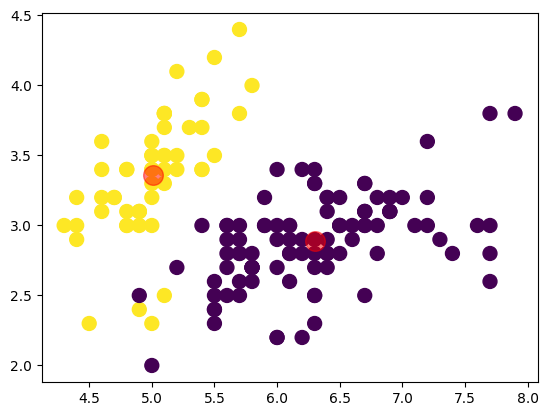

In [17]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

Cek Nilai SSE

In [18]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


Implementasi Metode Elbow

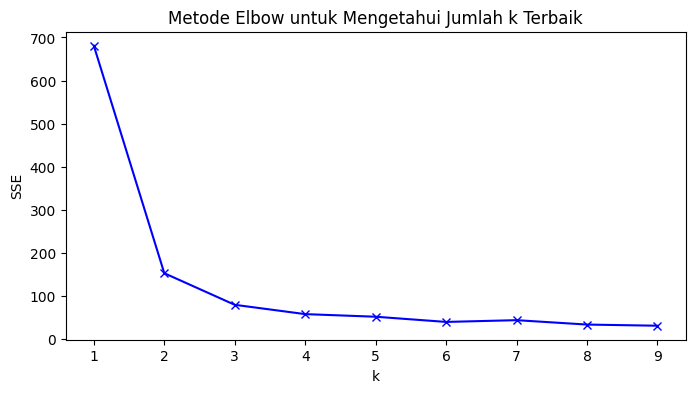

In [20]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

Cek Nilai SSE setiap K

In [21]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.317873214285726
k=5; SSE=51.26001612142648
k=6; SSE=39.19708292889162
k=7; SSE=43.270320105820126
k=8; SSE=33.05570407531277
k=9; SSE=30.378204545454555


# Praktikum 2


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

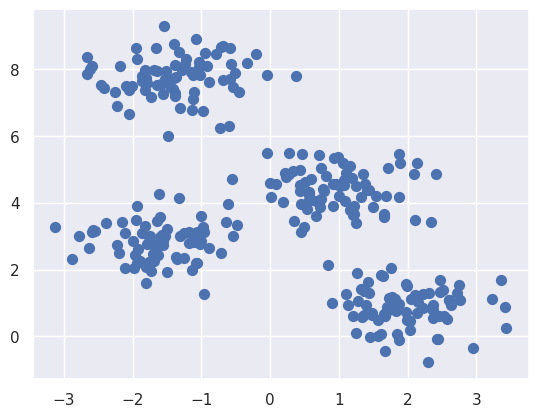

In [23]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

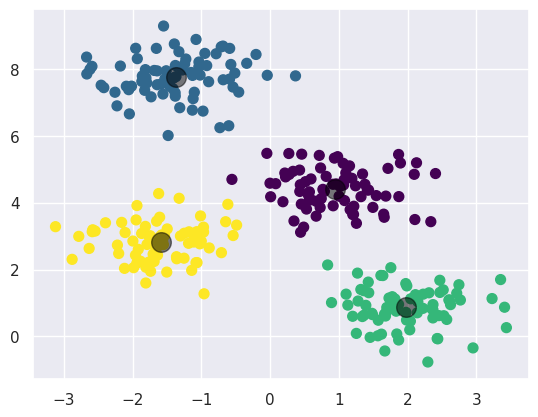

In [25]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

Algoritma Expectation-Maximization



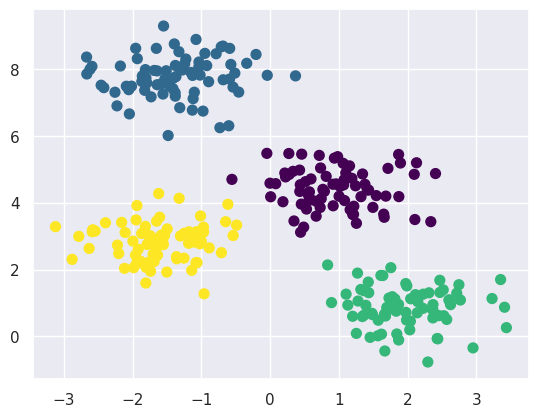

In [26]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

Perubahan random



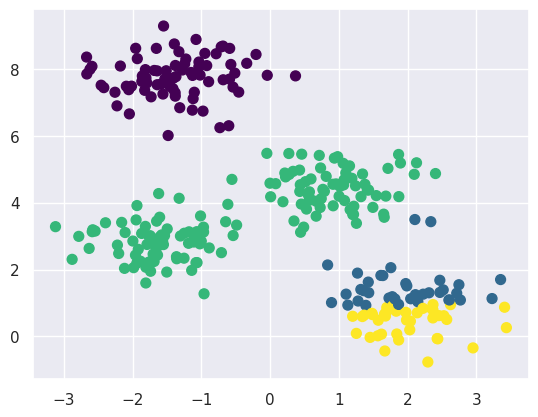

In [27]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

Optimalisasi Jumlah Klaster



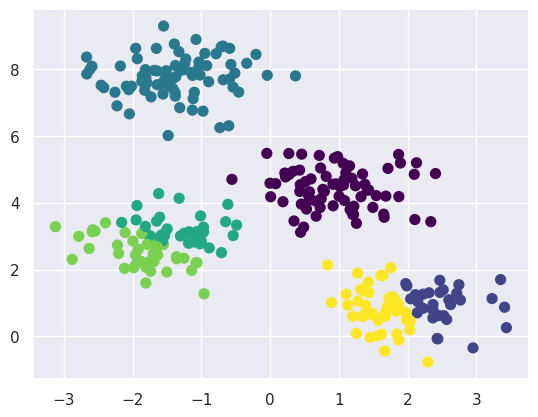

In [28]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

Batas Klaster yang Tidak Selalu Linier



In [29]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

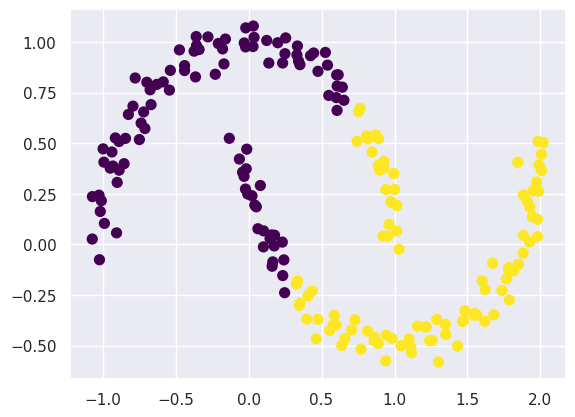

In [30]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


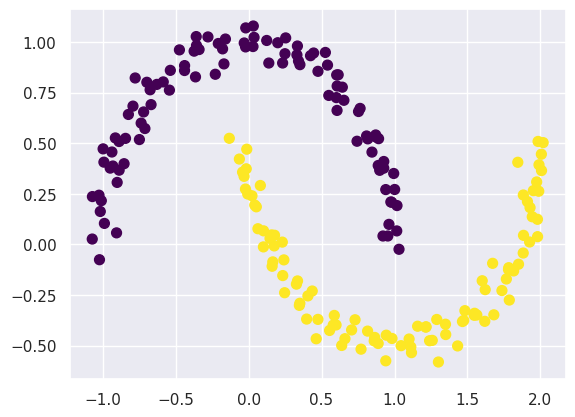

In [31]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

Contoh Kasus 1: Karakter Angka



In [32]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

Menerapkan K-Means

In [33]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

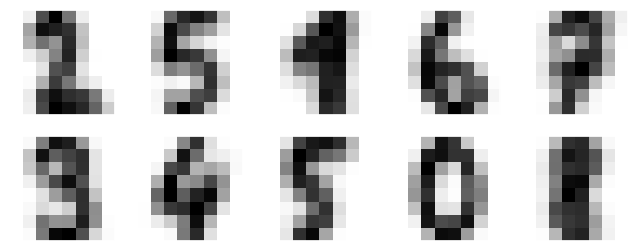

In [34]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [36]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

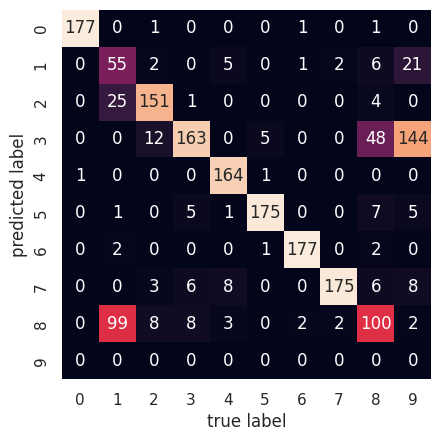

In [38]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [39]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

# Studi Kasus 2: Kompresi Citra



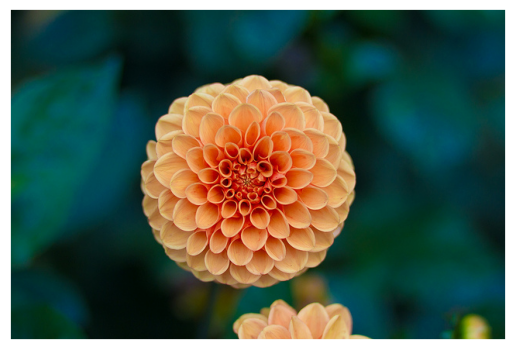

In [40]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [41]:
flower.shape

(427, 640, 3)

In [42]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [43]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

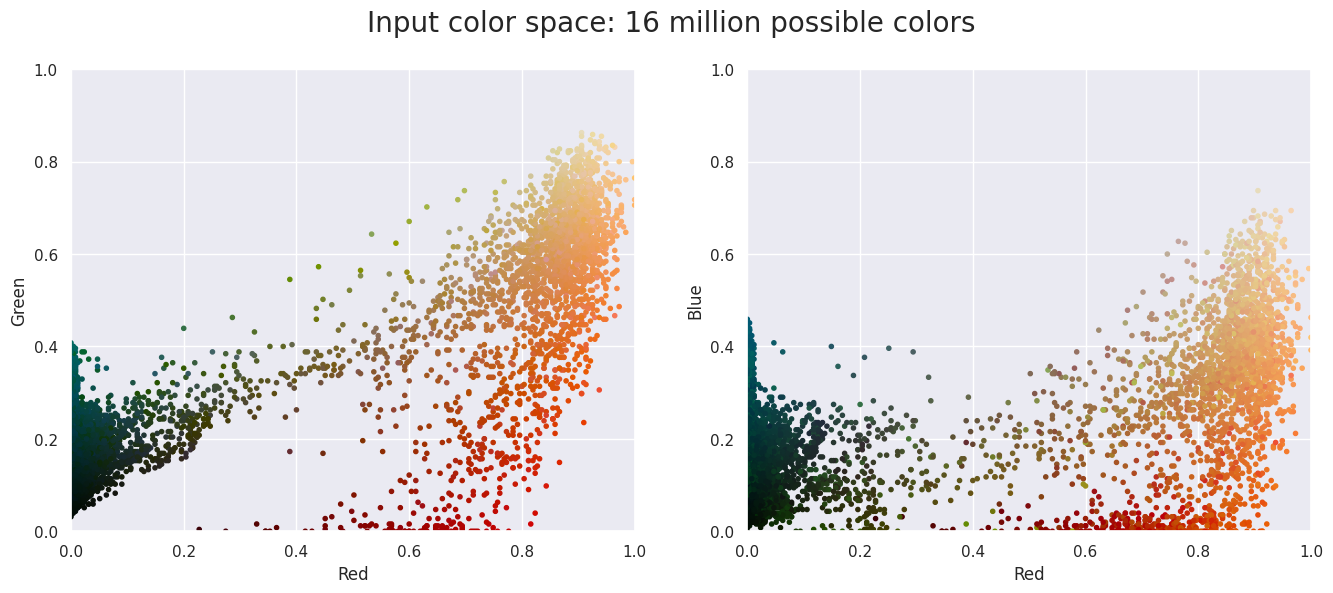

In [44]:
plot_pixels(data, title='Input color space: 16 million possible colors')

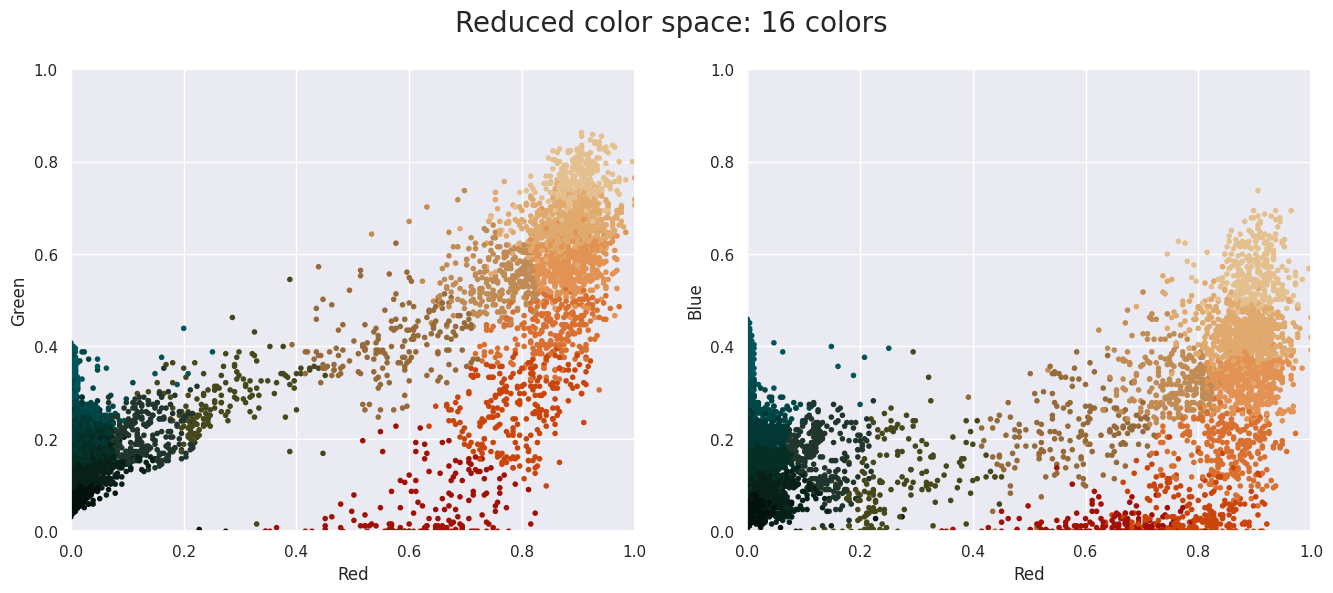

In [45]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

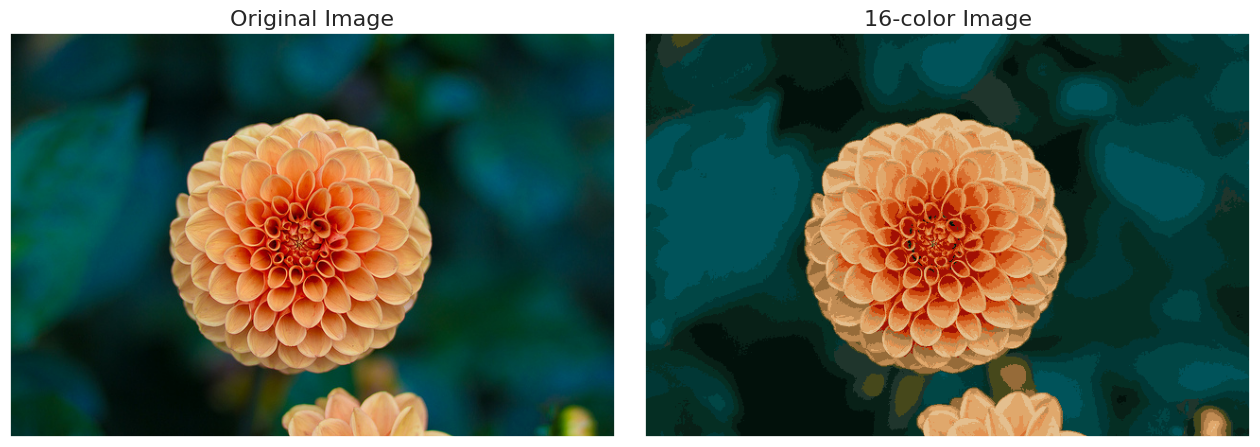

In [46]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# Praktikum 3


Pembuatan Dataset Sintetis


In [48]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

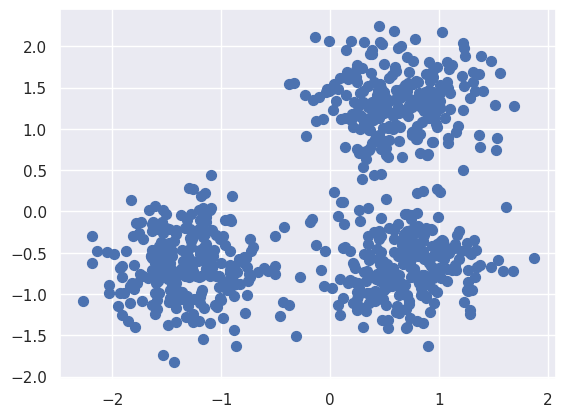

In [55]:
import matplotlib.pyplot as plt

(X[:, 0], X[:, 1])
plt.scatter(X[:, 0], X[:, 1], s=50);

Compute DBSCAN


In [54]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


Evaluasi Kualitas Klasterisasi


In [57]:
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


Visualisasi Hasil Klasterisasi


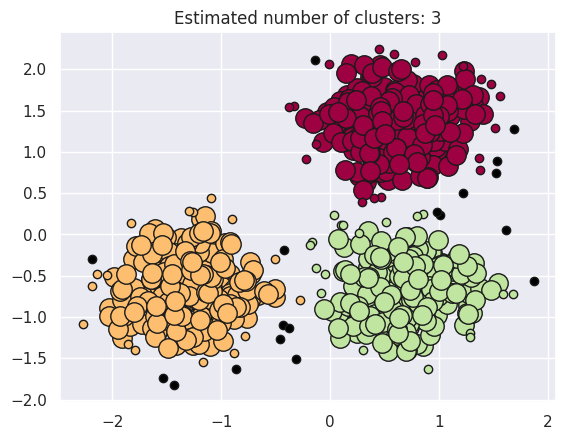

In [59]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    # Plot Core Samples
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # Plot Non-Core Samples (Boundary Points)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# Tugas Praktikum


## 1. Tugas K-Means


In [1]:
# Buatlah sebuah model K-Means dengan ketentuan,
# 1. Gunakan data 'Mall_Customers.csv'
# 2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
# 3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


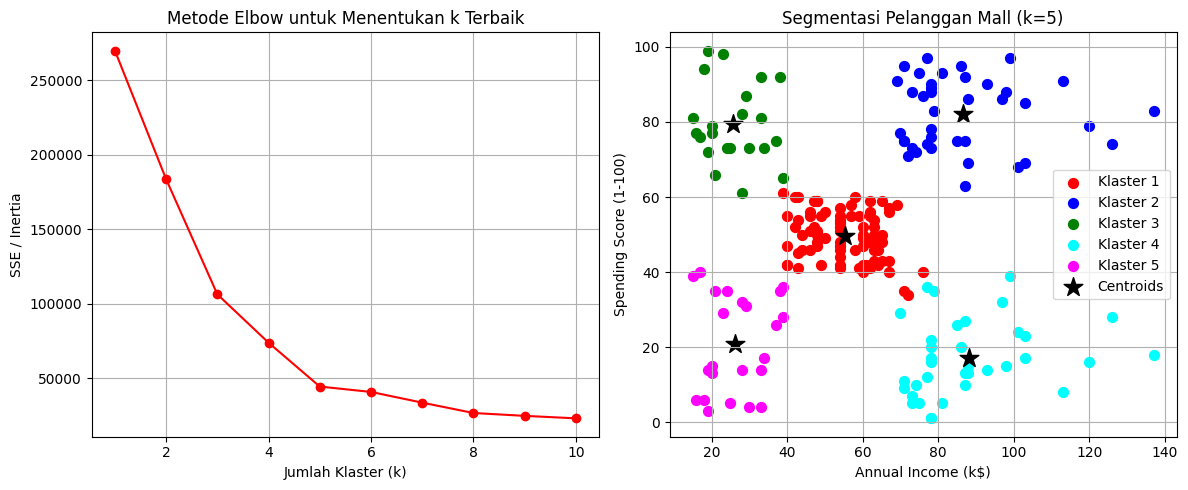

In [2]:
# 1. Memilih fitur yang tepat untuk clustering
# Kita mengambil kolom indeks ke-3 (Annual Income) dan ke-4 (Spending Score)
X_mall = df.iloc[:, [3, 4]].values

# 2. Menentukan jumlah k terbaik menggunakan Metode Elbow
sse_mall = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_mall)
    sse_mall.append(kmeans.inertia_)

# Plot grafik Elbow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), sse_mall, marker='o', color='red')
plt.title('Metode Elbow untuk Menentukan k Terbaik')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE / Inertia')
plt.grid(True)

# 3. Membuat model K-Means dengan k terbaik (k = 5)
# Berdasarkan kurva Elbow, siku terbentuk paling jelas di k = 5
k_optimal = 5
kmeans_optimal = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
y_kmeans_mall = kmeans_optimal.fit_predict(X_mall)

# Visualisasi hasil klasterisasi
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(k_optimal):
    plt.scatter(
        X_mall[y_kmeans_mall == i, 0],
        X_mall[y_kmeans_mall == i, 1],
        s=50,
        c=colors[i],
        label=f'Klaster {i+1}'
    )

# Plot pusat klaster (centroids)
centroids = kmeans_optimal.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='*', label='Centroids')
plt.title('Segmentasi Pelanggan Mall (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 2. Tugas DBSCAN



1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
* ` eps = 0.05, 0.1, 0.3, 0.5`
* `min_samples = 3, 10, 20`
* Catat perubahan klaster, noise, dan kualitas evaluasi.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Membuat dataset make_moons dan melakukan normalisasi
X_moons, y_moons_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# 2. Menjalankan DBSCAN awal (eps=0.2, min_samples=5)
db_moons = DBSCAN(eps=0.2, min_samples=5).fit(X_moons_scaled)
labels_moons = db_moons.labels_

# Menghitung jumlah klaster dan noise
n_clusters_moons = len(set(labels_moons)) - (1 if -1 in labels_moons else 0)
n_noise_moons = list(labels_moons).count(-1)

print(f"--- Hasil DBSCAN Awal (eps=0.2, min_samples=5) ---")
print(f"Estimasi jumlah klaster: {n_clusters_moons}")
print(f"Estimasi jumlah titik noise: {n_noise_moons}\n")

# 3. Evaluasi Kualitas Klasterisasi dengan Berbagai Metrik
print("--- Metrik Evaluasi ---")
print(f"Homogeneity: {metrics.homogeneity_score(y_moons_true, labels_moons):.3f}")
print(f"Completeness: {metrics.completeness_score(y_moons_true, labels_moons):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_moons_true, labels_moons):.3f}")
print(f"Adjusted Rand Index (ARI): {metrics.adjusted_rand_score(y_moons_true, labels_moons):.3f}")
print(f"Adjusted Mutual Information (AMI): {metrics.adjusted_mutual_info_score(y_moons_true, labels_moons):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_moons_scaled, labels_moons):.3f}")

--- Hasil DBSCAN Awal (eps=0.2, min_samples=5) ---
Estimasi jumlah klaster: 2
Estimasi jumlah titik noise: 0

--- Metrik Evaluasi ---
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index (ARI): 1.000
Adjusted Mutual Information (AMI): 1.000
Silhouette Coefficient: 0.391


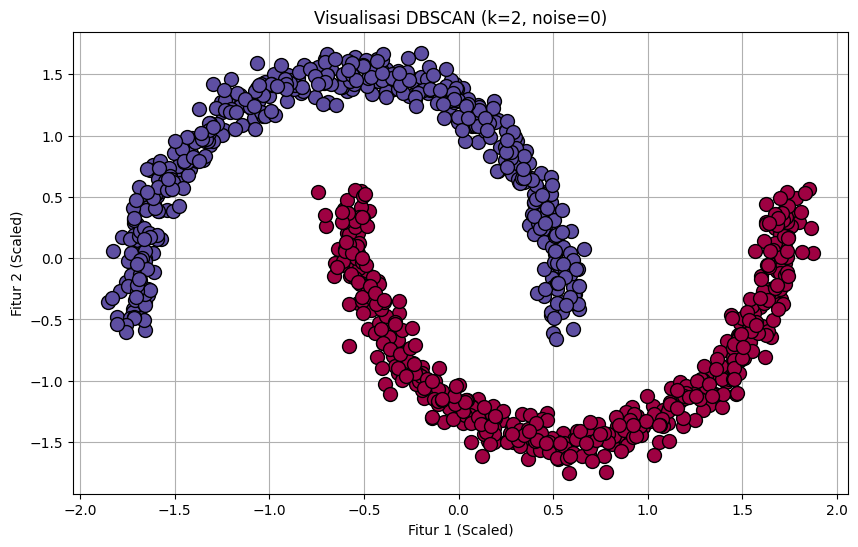

In [4]:
# 4. Visualisasi Hasil DBSCAN Awal
unique_moons_labels = set(labels_moons)
core_samples_mask = np.zeros_like(labels_moons, dtype=bool)
core_samples_mask[db_moons.core_sample_indices_] = True

plt.figure(figsize=(10, 6))
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_moons_labels))]

for k, col in zip(unique_moons_labels, colors):
    if k == -1:
        # Warna hitam untuk noise
        col = [0, 0, 0, 1]

    class_member_mask = (labels_moons == k)

    # Plot Core Samples (Titik Besar)
    xy_core = X_moons_scaled[class_member_mask & core_samples_mask]
    plt.plot(
        xy_core[:, 0],
        xy_core[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=10,
        label=f'Klaster {k} (Core)' if k != -1 else 'Noise'
    )

    # Plot Non-Core/Boundary Samples (Titik Kecil)
    xy_boundary = X_moons_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy_boundary[:, 0],
        xy_boundary[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=5
    )

plt.title(f"Visualisasi DBSCAN (k={n_clusters_moons}, noise={n_noise_moons})")
plt.xlabel("Fitur 1 (Scaled)")
plt.ylabel("Fitur 2 (Scaled)")
plt.grid(True)
plt.show()

In [5]:
# 5. Eksperimen Parameter eps dan min_samples
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print(f"{'eps':<6} | {'min_samp':<8} | {'Klaster':<8} | {'Noise':<6} | {'V-measure':<10} | {'Silhouette':<10}")
print("-" * 62)

for eps in eps_values:
    for min_samples in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=min_samples).fit(X_moons_scaled)
        labels_exp = db_exp.labels_

        n_cl_exp = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)
        n_ns_exp = list(labels_exp).count(-1)

        # Menghitung metrik (V-measure dan Silhouette)
        v_meas = metrics.v_measure_score(y_moons_true, labels_exp)
        # Silhouette hanya bisa dihitung jika jumlah klaster > 1 dan < n_samples
        if 1 < n_cl_exp < len(X_moons_scaled):
            sil = metrics.silhouette_score(X_moons_scaled, labels_exp)
            sil_str = f"{sil:.3f}"
        else:
            sil_str = "N/A"

        print(f"{eps:<6} | {min_samples:<8} | {n_cl_exp:<8} | {n_ns_exp:<6} | {v_meas:<10.3f} | {sil_str:<10}")

eps    | min_samp | Klaster  | Noise  | V-measure  | Silhouette
--------------------------------------------------------------
0.05   | 3        | 69       | 186    | 0.257      | 0.113     
0.05   | 10       | 3        | 970    | 0.049      | -0.294    
0.05   | 20       | 0        | 1000   | 0.000      | N/A       
0.1    | 3        | 2        | 14     | 0.943      | 0.252     
0.1    | 10       | 7        | 57     | 0.571      | 0.162     
0.1    | 20       | 6        | 850    | 0.155      | -0.360    
0.3    | 3        | 2        | 0      | 1.000      | 0.391     
0.3    | 10       | 2        | 0      | 1.000      | 0.391     
0.3    | 20       | 2        | 0      | 1.000      | 0.391     
0.5    | 3        | 2        | 0      | 1.000      | 0.391     
0.5    | 10       | 2        | 0      | 1.000      | 0.391     
0.5    | 20       | 2        | 0      | 1.000      | 0.391     
